<a href="https://colab.research.google.com/github/belokonr/Breast-Cancer-Study/blob/main/notebooks/02_ModelBuilding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, log_loss, accuracy_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

rf_df_raw = pd.read_csv('https://raw.githubusercontent.com/belokonr/Breast-Cancer-Study/refs/heads/main/rf_df_bc.csv')

In [2]:
rf_df_raw.head()

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
0,2013,55,1,1,0,0,1,0,2,30,0,0,2
1,2013,55,1,1,0,0,1,0,2,35,1,0,1
2,2013,55,1,1,0,0,1,0,3,25,1,0,1
3,2013,55,1,1,0,0,1,0,3,35,0,0,1
4,2013,55,1,1,0,0,2,0,1,30,0,0,1


In [22]:
rf_df = rf_df_raw.loc[rf_df_raw.index.repeat(rf_df_raw['count'])].reset_index(drop=True)

In [23]:
rf_df.head()

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
0,2013,55,1,1,0,0,1,0,2,30,0,0,2
1,2013,55,1,1,0,0,1,0,2,30,0,0,2
2,2013,55,1,1,0,0,1,0,2,35,1,0,1
3,2013,55,1,1,0,0,1,0,3,25,1,0,1
4,2013,55,1,1,0,0,1,0,3,35,0,0,1


In [35]:
sumstats = rf_df[['BIRADS_breast_density', 'age_group_5_years', 'bmi_group', 'biophx', 'breast_cancer_history', 'race_eth', 'first_degree_hx', 'age_menarche', 'age_first_birth', 'current_hrt', 'menopaus']]

sumstats.describe().loc[['mean', 'std', 'min', 'max']].T

,mean,std,min,max
BIRADS_breast_density,2.448385,0.743321,1.0,4.0
age_group_5_years,57.240023,11.761068,18.0,85.0
bmi_group,21.842425,9.577252,10.0,35.0
biophx,0.251845,0.434073,0.0,1.0
breast_cancer_history,0.073640,0.261185,0.0,1.0
race_eth,1.769676,1.275903,1.0,6.0
first_degree_hx,0.181308,0.385273,0.0,1.0
age_menarche,0.899689,0.672925,0.0,2.0
age_first_birth,2.011256,1.304284,0.0,4.0
current_hrt,0.015292,0.122714,0.0,1.0


# Logistic Regression: Sklearn

In [24]:
X1 = rf_df.drop(columns=['breast_cancer_history'])
y = rf_df['breast_cancer_history'].to_numpy()

# One-hot encode y and standardize X matrix
#y = pd.get_dummies(rf_df['breast_cancer_history']).to_numpy(dtype=float)

scaler = StandardScaler()
X = scaler.fit_transform(X1.to_numpy(dtype=float)).round(2)
#X = scaler.fit_transform(rf_df.drop(columns=['breast_cancer_history']), drop_first=True, dtype=int).to_numpy(dtype=float).round(2)
X

y

array([0, 0, 0, ..., 0, 0, 0])

In [25]:
# Fit a logistic reg of all vars on
#X = rf_df.drop(columns=['breast_cancer_history']).to_numpy()
#y = rf_df['breast_cancer_history'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

X_train.shape, X_test.shape


((386935, 12), (257957, 12))

In [26]:
print("Class balance (train):", np.mean(y_train))

Class balance (train): 0.07364544432527427


In [27]:
print("Class balance (train):", np.mean(y_test))

Class balance (train): 0.07363242710994468


In [28]:
model = LogisticRegression().fit(X_train, y_train)

In [29]:
model.predict_proba(X_train)

array([[7.10978197e-01, 2.89021803e-01],
       [9.63715615e-01, 3.62843851e-02],
       [9.94154529e-01, 5.84547062e-03],
       ...,
       [9.99999993e-01, 7.01988805e-09],
       [9.07366419e-01, 9.26335812e-02],
       [9.93362215e-01, 6.63778482e-03]])

Train accuracy: 0.9249667256774393
Test  accuracy: 0.9244990444143791


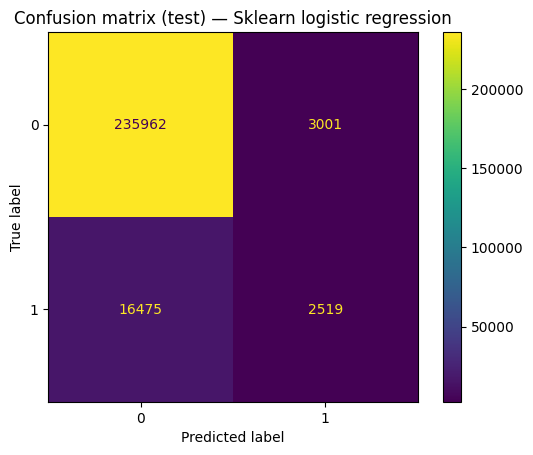

In [30]:
# Evaluate on train/test
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, yhat_train))
print("Test  accuracy:", accuracy_score(y_test, yhat_test))
#print("Test  log-loss:", log_loss(y_test, np.column_stack([1-f_hat(Phi_test, w_hat), f_hat(Phi_test, w_hat)])))

ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test))
plt.title("Confusion matrix (test) — Sklearn logistic regression")
plt.show()

In [24]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[ 3.94984788e-02  5.92442527e-01 -5.29852779e-01 -2.25428933e-01
  -3.38626927e-02  2.49306670e-02 -3.75276029e-02 -2.64590303e-01
  -1.01422675e-02 -1.91347991e-01  6.59664094e-01 -1.27754101e+01]]
Intercept: [-8.49400245]


In [14]:
Xtr, Xte = X_train, X_test
ytr, yte = y_train, y_test

try:
    clf_none = LogisticRegression(penalty="none", solver="lbfgs", max_iter=5000)
    clf_none.fit(Xtr, ytr)
    print("sklearn LogisticRegression(penalty='none') succeeded.")
except Exception:
    clf_none = LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000)
    clf_none.fit(Xtr, ytr)
    print("sklearn fallback: very weak L2 via large C.")

print("Test accuracy (sklearn):", clf_none.score(Xte, yte))

sklearn fallback: very weak L2 via large C.
Test accuracy (sklearn): 0.924502921029474


In [15]:
# Regularized logistic regression (L2, L1, Elastic Net) with scaling
# Note: there are different solvers for these regularized methods

pipe_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf_l2", LogisticRegression(penalty="l2", max_iter=5000))
])

pipe_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf_l1", LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000))
])

pipe_en = Pipeline([
    ("scaler", StandardScaler()),
    ("clf_en", LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga", max_iter=5000))
])

for name, model in [("L2 (ridge)", pipe_l2), ("L1 (lasso)", pipe_l1), ("ElasticNet", pipe_en)]:
    model.fit(Xtr, ytr)
    acc = model.score(Xte, yte)
    print(f"{name:>10s} test accuracy = {acc:.3f}")

L2 (ridge) test accuracy = 0.925
L1 (lasso) test accuracy = 0.925
ElasticNet test accuracy = 0.924


# Logistic Regression: Manual Implementation

In [16]:
def sigmoid(z):
    """Sigmoid / logistic function."""
    z = np.asarray(z)
    return 1 / (1 + np.exp(-z))


def add_intercept(X):
    """Add intercept column of ones to a 2D array X."""
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(X.shape[0]), X])


def bce_loss(y_true, f_hat, eps=1e-12):
    """
    Binary cross-entropy / log-loss (average over samples).
    y_true in {0,1}, f_hat in (0,1).
    """
    y_true = np.asarray(y_true).reshape(-1)
    f_hat = np.asarray(f_hat).reshape(-1)
    f_hat = np.clip(f_hat, eps, 1 - eps) # this handles edge cases so we don't do log(0) or something silly
    return -np.mean(y_true * np.log(f_hat) + (1 - y_true) * np.log(1 - f_hat))


def f_hat(Phi, w):
    """Predicted probability P(y=1|x) for logistic regression."""
    return sigmoid(Phi @ w)


#here threshold os 0.5, but this is a tuning param that we can change to see which model works best
def predict_label(Phi, w, threshold=0.5): # cast probability to 0 or 1 based on threshold
    """Hard class prediction in {0,1}."""
    return (f_hat(Phi, w) >= threshold).astype(int)

In [17]:
def logistic_loss(Phi, y, w):
    """Average binary cross-entropy for logistic regression."""
    p_hat = f_hat(Phi, w)
    return bce_loss(y, p_hat)


def logistic_grad(Phi, y, w):
    """Gradient of average log-loss."""
    n = Phi.shape[0]
    y = np.asarray(y).reshape(-1)
    p_hat = f_hat(Phi, w)
    # (1/n) Phi^T (p_hat - y) # one way of doing it
    return (1/n) * (Phi.T @ (p_hat - y)) # this is the martix form of the sum of f_hat(xi)-yi phi(xi)

def fit_logreg_gd(Phi, y, lr=0.2, n_steps=4000, w0=None, verbose=False):
    """
    Fit logistic regression by (batch) gradient descent on average log-loss.
    Returns (w_hat, losses).
    """
    rng = np.random.default_rng(0)
    p = Phi.shape[1]
    # randomly initializes the weights if they are not specified in the function arguments
    w = rng.standard_normal(p) if w0 is None else np.array(w0, dtype=float).copy()

    losses = []
    for t in range(n_steps):
        loss = logistic_loss(Phi, y, w)
        losses.append(loss)

        g = logistic_grad(Phi, y, w)
        w = w - lr * g

        if verbose and (t % 500 == 0 or t == n_steps - 1):
            print(f"step {t:4d}  loss={loss:.4f}")

    return w, np.array(losses)

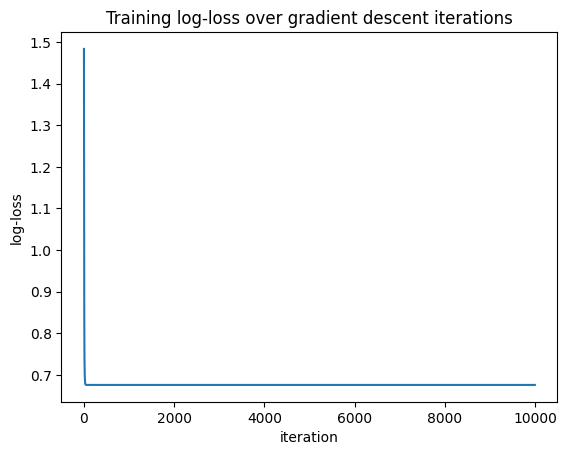

w_hat (GD): [ 0.01604521  0.17565095 -0.02484818  0.00842763  0.00121296  0.02089009
  0.00616391 -0.0389307  -0.03500379 -0.00380103  0.29646418 -0.0695066 ]


In [18]:
w_hat, losses = fit_logreg_gd(X_train, y_train, lr=0.5, n_steps=10000, verbose=False)

plt.figure()
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("log-loss")
plt.title("Training log-loss over gradient descent iterations")
plt.show()

print("w_hat (GD):", w_hat)

Train accuracy: 0.6980991639422642
Test  accuracy: 0.6975891330725663
Test  log-loss: 0.6758344950767173


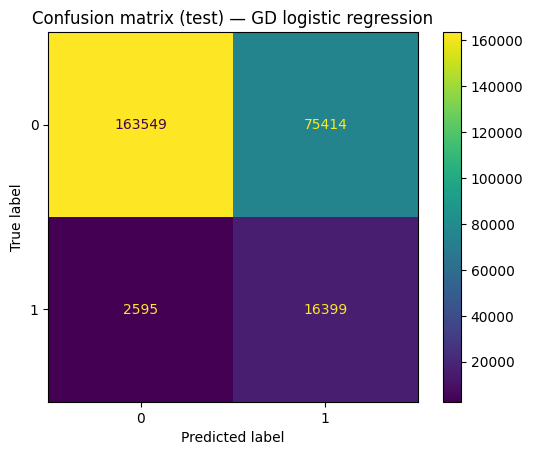

In [19]:
# Evaluate on train/test
yhat_train = predict_label(X_train, w_hat)
yhat_test = predict_label(X_test, w_hat)

print("Train accuracy:", accuracy_score(y_train, yhat_train))
print("Test  accuracy:", accuracy_score(y_test, yhat_test))
print("Test  log-loss:", log_loss(y_test, np.column_stack([1-f_hat(X_test, w_hat), f_hat(X_test, w_hat)])))

ConfusionMatrixDisplay.from_predictions(y_test, yhat_test)
plt.title("Confusion matrix (test) — GD logistic regression")
plt.show()

# Random Forest

In [12]:
X = rf_df.drop(columns=['breast_cancer_history', 'count'])
y = rf_df['breast_cancer_history'].to_numpy()
feature_names = list(rf_df.drop(columns=['breast_cancer_history', 'count']).columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)


In [13]:
rf_5 = RandomForestClassifier(criterion='gini', max_depth=20, random_state=0)
rf_5.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=0)

In [14]:
# forest performance
prec=precision_score(y_test, rf_5.predict(X_test))
rec=recall_score(y_test, rf_5.predict(X_test))
acc=accuracy_score(y_test, rf_5.predict(X_test))
f1=f1_score(y_test, rf_5.predict(X_test))

print(f'Performance of random forest evaluated on validation set:\nprecision: {prec}\nrecall: {rec}\naccuracy: {acc}\nf1: {f1}')

metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'Accuracy', 'F1 Score'],
    'Score': [prec, rec, acc, f1]
})

metrics.style.hide(axis='index').format({'Score': '{:.4f}'})

Performance of random forest evaluated on validation set:
precision: 0.32851333032083146
recall: 0.07677685077621713
accuracy: 0.9207002690360446
f1: 0.12446498887176853


Metric,Score
Precision,0.3285
Recall,0.0768
Accuracy,0.9207
F1 Score,0.1245


In [15]:
# Feature importance from the random forest (using permutation importance)

#fit forest to full data set
rf_5.fit(X, y)

result = permutation_importance(
    rf_5, X, y, n_repeats=10, random_state=42
)

# You can then access the mean importance scores via result.importances_mean
perm_importances = pd.Series(result.importances_mean, index=feature_names).sort_values()

plt.figure(figsize=(6,6))
plt.barh(perm_importances.index, perm_importances.values)
plt.xlabel("Feature importance (permutation)")
plt.title("Breast Cancer: random forest feature importances (permutation)")
plt.show()

KeyboardInterrupt: 

# Random Forest on Breast Density

In [19]:
X = rf_df.drop(columns=['BIRADS_breast_density', 'count', 'year', 'breast_cancer_history'])
y = rf_df['BIRADS_breast_density'].to_numpy()
feature_names = list(X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)


In [17]:
rf_bd = RandomForestClassifier(criterion='gini', max_depth=20, random_state=0)
rf_bd.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=0)

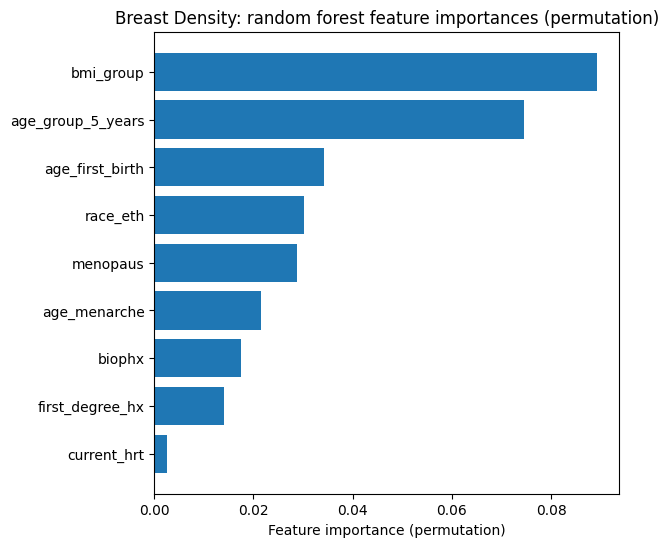

In [34]:
# Feature importance from the random forest (using permutation importance)

#fit forest to full data set
rf_bd.fit(X, y)

result = permutation_importance(
    rf_bd, X, y, n_repeats=10, random_state=42
)

# You can then access the mean importance scores via result.importances_mean
perm_importances = pd.Series(result.importances_mean, index=feature_names).sort_values()

plt.figure(figsize=(6,6))
plt.barh(perm_importances.index, perm_importances.values)
plt.xlabel("Feature importance (permutation)")
plt.title("Breast Density: random forest feature importances (permutation)")
plt.show()